En este proyecto se intentará simular una situación real de un cliente solicitando un servicio de analítica a partir de la información que dispone. 

Prompt:

Simula una situación donde eres un cliente que quiere contratar un servicio de analítica de datos a partir de información disponible que posees. Los datos que posees tienen las siguientes columnas:

---columnas---

Ship Mode	Segment	Country	City	State	Postal Code	Region	Category	Sub-Category	Sales	Quantity	Discount	Profit



---Instrucciones---

Dame los requisitos del proyecto:

- Objetivos aproximados o noción de estos (Ten en cuenta que el cliente tal vez no tenga ni idea de qué hacer con sus datos o puede tener una noción). Pueden ser múltiples, desde información descriptiva hasta información a partir del modelado estadistico o machine learning
- Entregables esperados (aproximados)
- Tiempo de entrega 
- Recursos disponibles


# 1.- Entender el problema y definir el objetivo

📌 Contexto del cliente (simulación)

Soy una empresa que vende productos a nivel nacional y tengo un registro de mis ventas en una base de datos. Cada fila representa una transacción y contiene información como el modo de envío, el segmento del cliente, la ciudad, el estado, la región, la categoría y subcategoría del producto, además de las métricas de ventas, cantidad, descuento y ganancia.

No sé exactamente qué tan profundo puedo llegar con este análisis, pero quiero aprovechar estos datos para entender mejor mi negocio y tomar decisiones más inteligentes.

## 1.1.- Objetivos aproximados

1. **Análisis descriptivo:**
    - Identificar patrones de ventas por región, estado y ciudad.
    - Analizar cuáles son los productos y categorías más rentables.
    - Ver el impacto de los descuentos en las ganancias.
    - Detectar tendencias de compra por segmento de cliente.
2. **Análisis diagnóstico:**
    - Entender por qué ciertas regiones o productos tienen márgenes más bajos.
    - Evaluar si el modo de envío influye en el margen de ganancia.
3. **Análisis predictivo / estadístico (en caso de ser posible):**
    - Predecir ventas futuras por región o categoría usando series de tiempo o modelos de machine learning.
    - Identificar clientes o segmentos con mayor probabilidad de compras repetidas.
4. **Análisis prescriptivo (opcional):**
    - Recomendaciones sobre asignación de inventario o ajustes de descuentos para maximizar beneficios.

## 1.2.- Entregables esperados (aproximados)

- **Dashboard interactivo** (en Power BI, Tableau o similar) con:
    - Ventas, ganancia y cantidad por región, ciudad, categoría y subcategoría.
    - Análisis de descuentos y su impacto en las ganancias.
    - Segmentación de clientes y patrones de compra.
- **Informe escrito** con hallazgos clave y conclusiones.
- **Modelos predictivos** (si aplican) con métricas de desempeño y escenarios simulados.
- **Recomendaciones accionables** para mejorar márgenes y priorizar ventas.

## 1.3.- Recursos disponibles

**Datos:**
- Archivo CSV/Excel con las columnas mencionadas y varios años de historial.

**Herramientas disponibles:**
- Microsoft Excel
- Power BI 
- Posibilidad de usar Python o R (instalados)

**Personal de apoyo:**
- Contacto interno para resolver dudas sobre los datos y su origen.

**Presupuesto:**
- Flexible, pero se requiere una propuesta con desglose de costos.

fuente de datos: https://www.kaggle.com/datasets/roopacalistus/superstore

# 2.- Obtener los datos

In [2]:

#importar librerias basicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [3]:
import pandas as pd

df_original = pd.read_csv("ventas_original.csv")
df_original.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 2.1.- Entender cada columna o variable

La tabla original:

| **Nombre en Español** | **Nombre en Inglés** | **Descripción**                                                                                                   |
| --------------------- | -------------------- | ----------------------------------------------------------------------------------------------------------------- |
| **Modo\_de\_envío**   | Ship Mode            | Tipo de servicio de envío utilizado para la entrega del pedido (ejemplo: Standard Class, Second Class, Same Day). |
| **Segmento**          | Segment              | Tipo de cliente al que se le realizó la venta (Consumer, Corporate, Home Office).                                 |
| **País**              | Country              | País en el cual se efectuó la venta (en este dataset: United States).                                             |
| **Ciudad**            | City                 | Ciudad en la que reside el cliente o se entregó el pedido.                                                        |
| **Estado**            | State                | Estado o provincia dentro del país donde se ubica el cliente.                                                     |
| **Código\_Postal**    | Postal Code          | Código postal de la dirección de envío del cliente.                                                               |
| **Región**            | Region               | División geográfica del país (South, West, East, Central).                                                        |
| **Categoría**         | Category             | Clasificación principal del producto vendido (Furniture, Office Supplies, Technology).                            |
| **Subcategoría**      | Sub-Category         | Subdivisión más específica de la categoría de producto (Bookcases, Chairs, Labels, Tables, etc.).                 |
| **Ventas**            | Sales                | Valor monetario de la venta (ingresos generados por el pedido).                                                   |
| **Cantidad**          | Quantity             | Número de unidades de producto vendidas en el pedido.                                                             |
| **Descuento**         | Discount             | Porcentaje de descuento aplicado a la venta (ejemplo: 0.20 = 20% de descuento).                                   |
| **Ganancia**          | Profit               | Utilidad neta obtenida tras la venta (Ventas - Costos - Descuentos).                                              |


Podemos normalizar la tabla con fines de tener mejor integridad en los datos. Una primera propuesta a la normalización de la tabla se encuentra en el archivo SQL adjunto en esta carpeta

In [6]:
# Cambiar los nombres de las columnas a español
df_original.columns = [
    'Modo_de_envío', 'Segmento', 'País', 'Ciudad', 'Estado', 'Código_Postal',
    'Región', 'Categoría', 'Subcategoría', 'Ventas', 'Cantidad', 'Descuento', 'Ganancia'
]
df_original.head()

,Modo_de_envío,Segmento,País,Ciudad,Estado,Código_Postal,Región,Categoría,Subcategoría,Ventas,Cantidad,Descuento,Ganancia
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [7]:
# Save the original DataFrame to a new CSV file
df_original.to_csv("ventas_original_español.csv", index=False)


# 3.- Exploración del dataset

In [3]:
import pandas as pd
df_original = pd.read_csv("ventas_original_español.csv")
df_original.head()

,Modo_de_envío,Segmento,País,Ciudad,Estado,Código_Postal,Región,Categoría,Subcategoría,Ventas,Cantidad,Descuento,Ganancia
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164



1. TAMAÑO DEL DATAFRAME
(9994, 13)

2. INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Modo_de_envío  9994 non-null   object 
 1   Segmento       9994 non-null   object 
 2   País           9994 non-null   object 
 3   Ciudad         9994 non-null   object 
 4   Estado         9994 non-null   object 
 5   Código_Postal  9994 non-null   int64  
 6   Región         9994 non-null   object 
 7   Categoría      9994 non-null   object 
 8   Subcategoría   9994 non-null   object 
 9   Ventas         9994 non-null   float64
 10  Cantidad       9994 non-null   int64  
 11  Descuento      9994 non-null   float64
 12  Ganancia       9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB

3. DICCIONARIO DE CATEGORÍAS (VARIABLES CATEGÓRICAS)

Columna: Modo_de_envío
Categorías: ['Seco

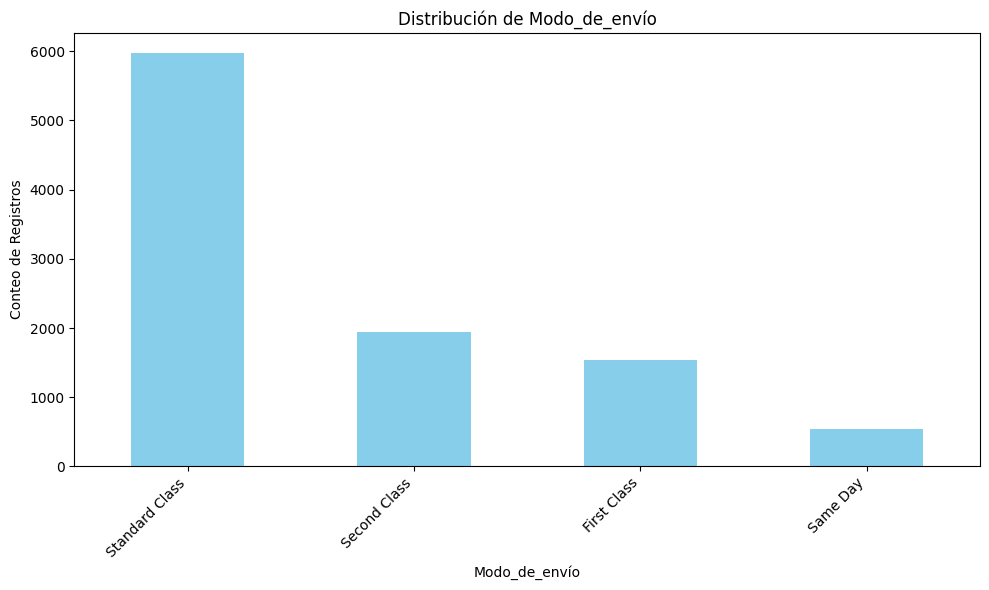

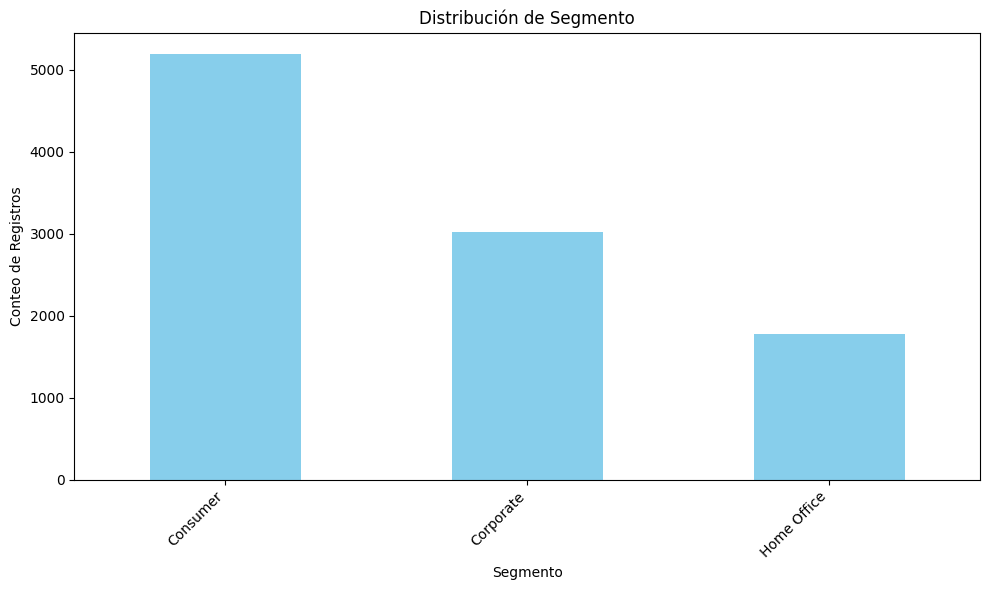

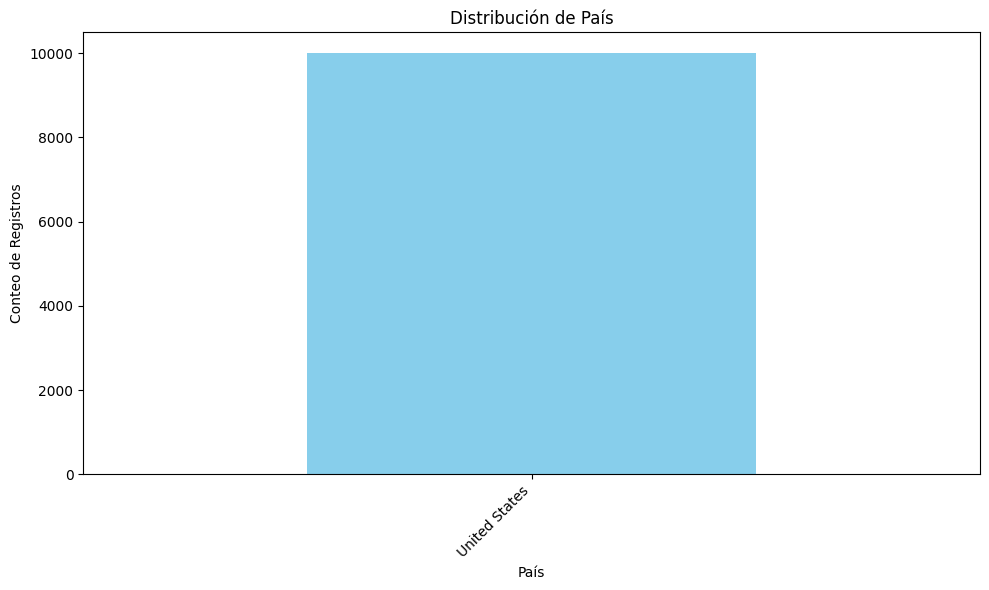

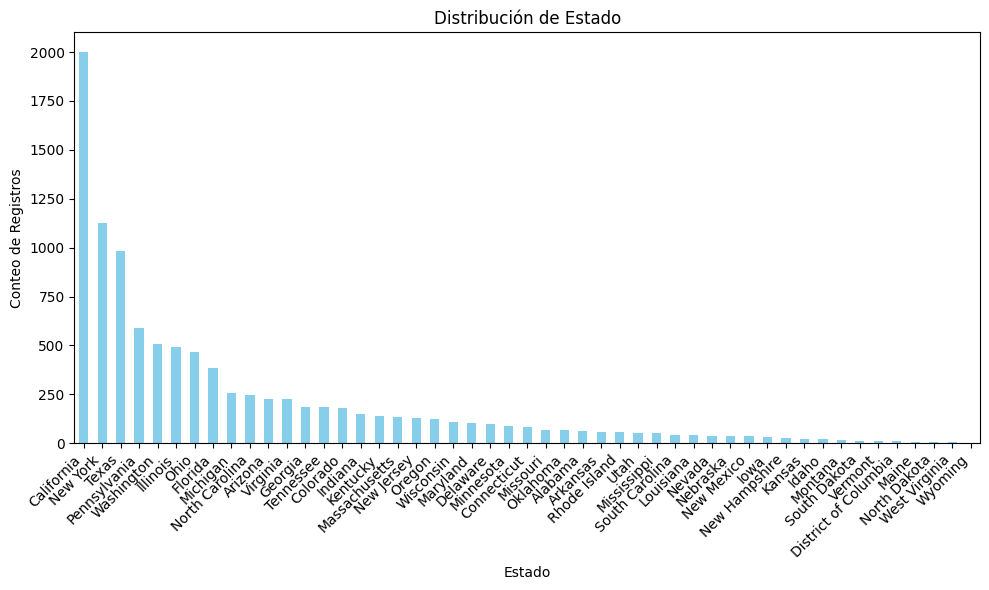

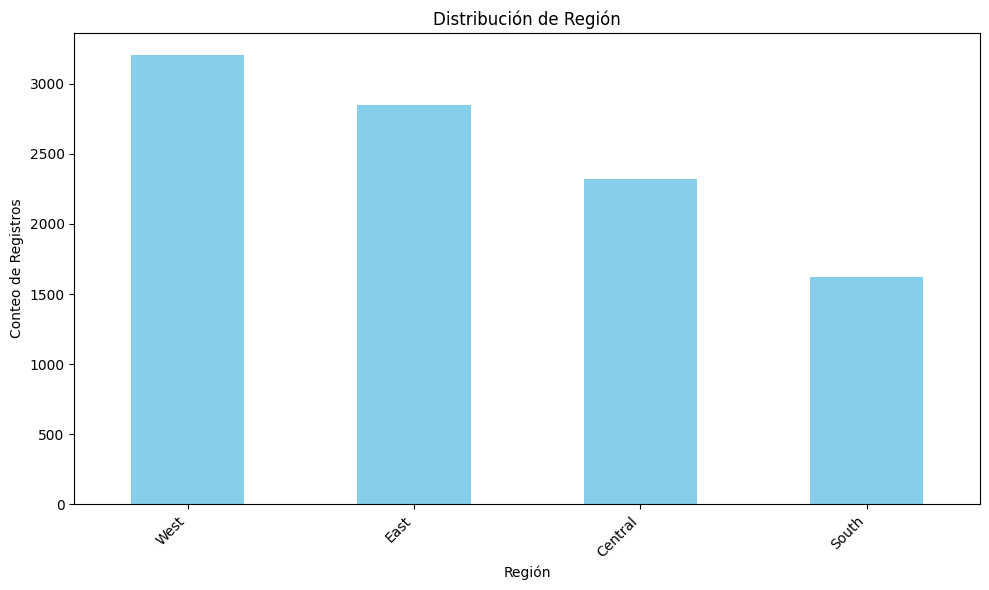

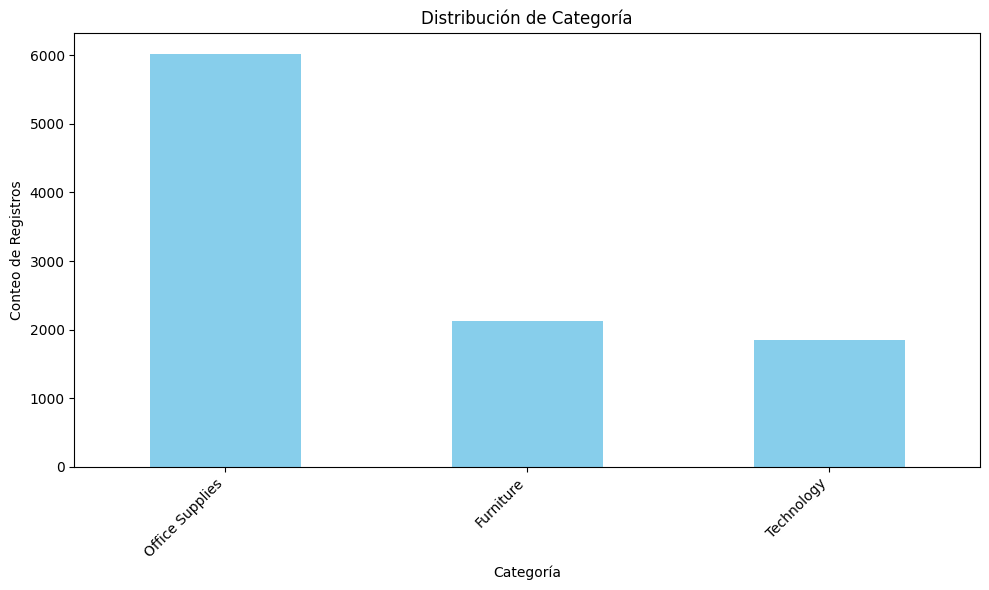

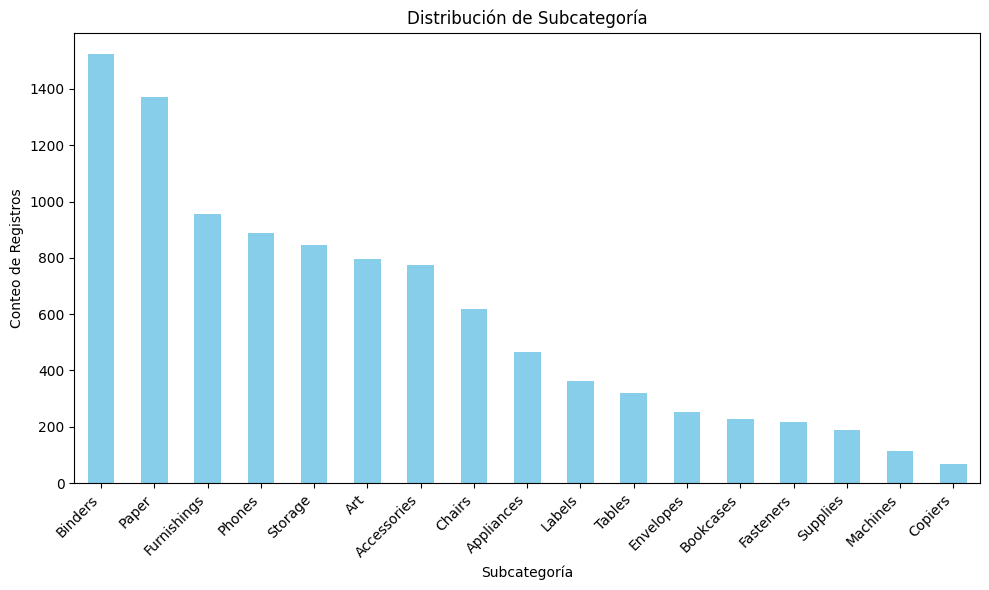


4. ESTADÍSTICAS DESCRIPTIVAS
       Código_Postal        Ventas     Cantidad    Descuento     Ganancia
count    9994.000000   9994.000000  9994.000000  9994.000000  9994.000000
mean    55190.379428    229.858001     3.789574     0.156203    28.656896
std     32063.693350    623.245101     2.225110     0.206452   234.260108
min      1040.000000      0.444000     1.000000     0.000000 -6599.978000
25%     23223.000000     17.280000     2.000000     0.000000     1.728750
50%     56430.500000     54.490000     3.000000     0.200000     8.666500
75%     90008.000000    209.940000     5.000000     0.200000    29.364000
max     99301.000000  22638.480000    14.000000     0.800000  8399.976000

5. VALORES FALTANTES
Modo_de_envío    0
Segmento         0
País             0
Ciudad           0
Estado           0
Código_Postal    0
Región           0
Categoría        0
Subcategoría     0
Ventas           0
Cantidad         0
Descuento        0
Ganancia         0
dtype: int64

6. DETECCIÓN DE OUTLI

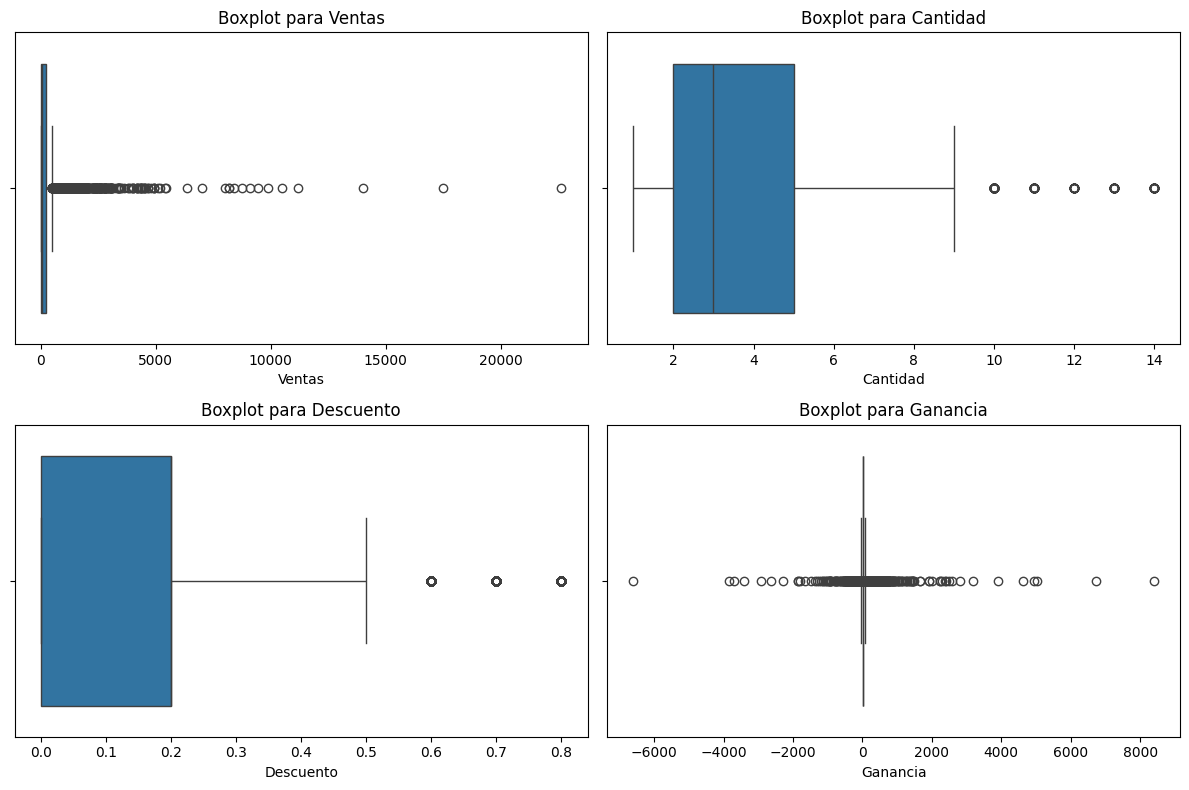


6.1. NÚMERO DE VALORES DUPLICADOS
Número de filas duplicadas en el DataFrame: 17

7. MATRIZ DE CORRELACIÓN


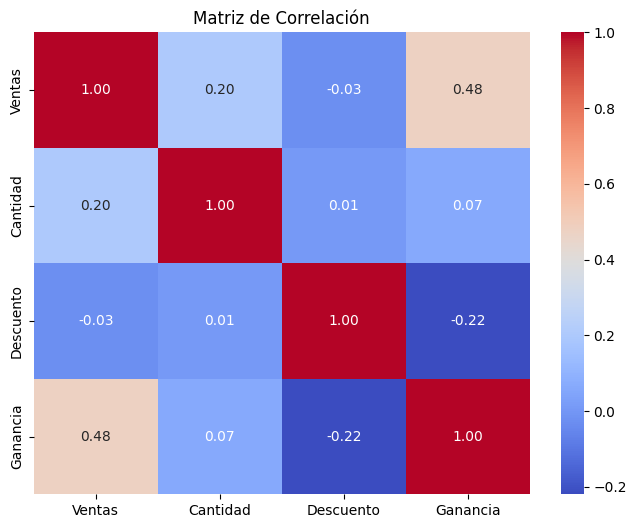


7.1. MATRIZ DE DISPERSIÓN (PAIRPLOT)


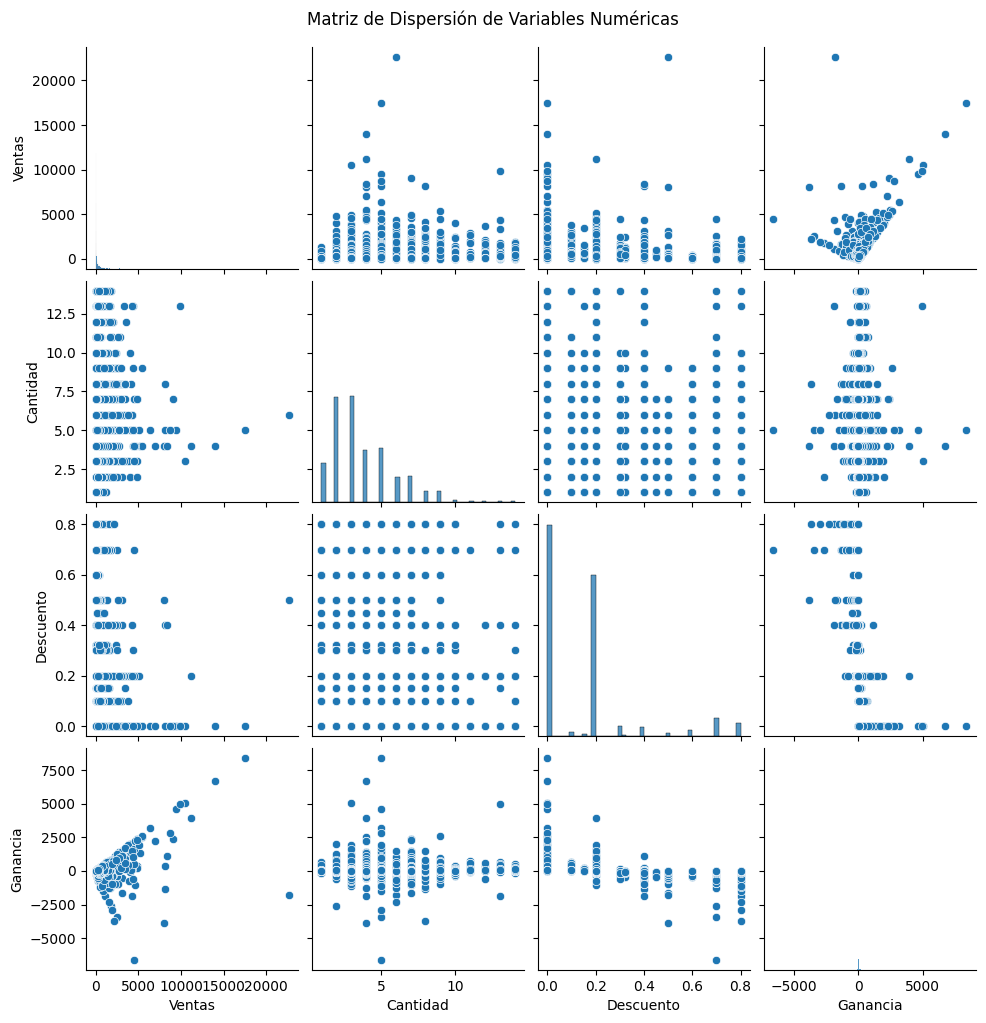


8. DISTRIBUCIÓN DE DATOS (QQ-PLOT)


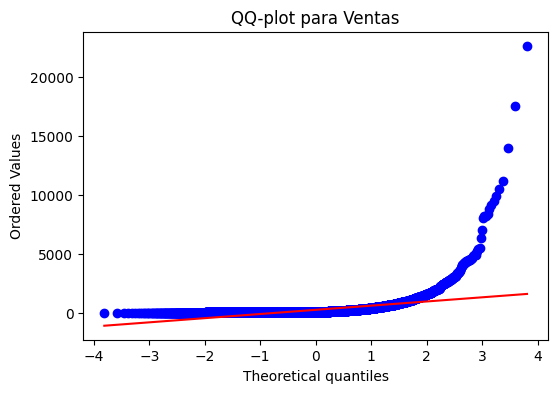

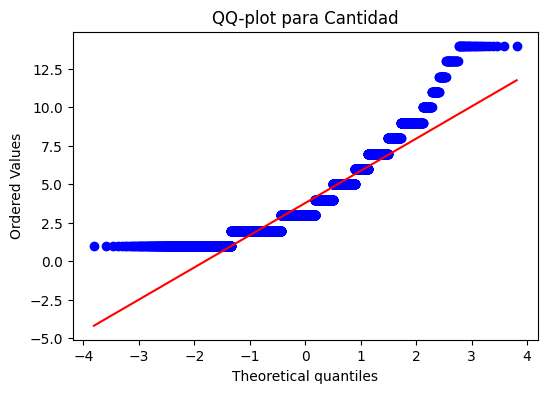

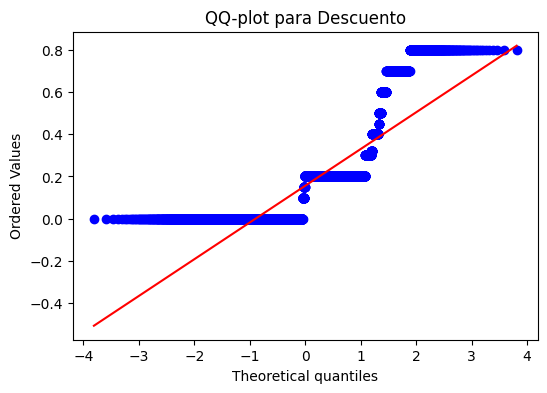

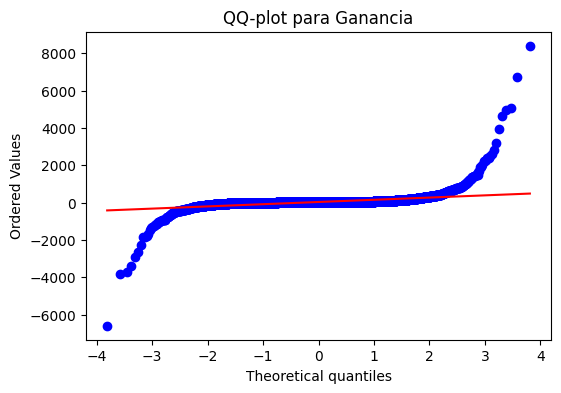


8.1. MEDIA, MODA Y MEDIANA DE VARIABLES NUMÉRICAS

Columna: Ventas
   Media: 229.86
   Mediana: 54.49
   Moda: 12.96

Columna: Cantidad
   Media: 3.79
   Mediana: 3.00
   Moda: 3.00

Columna: Descuento
   Media: 0.16
   Mediana: 0.20
   Moda: 0.00

Columna: Ganancia
   Media: 28.66
   Mediana: 8.67
   Moda: 0.00

8.2. DISTRIBUCIÓN DE DATOS NUMÉRICOS (HISTOGRAMAS Y KDE)


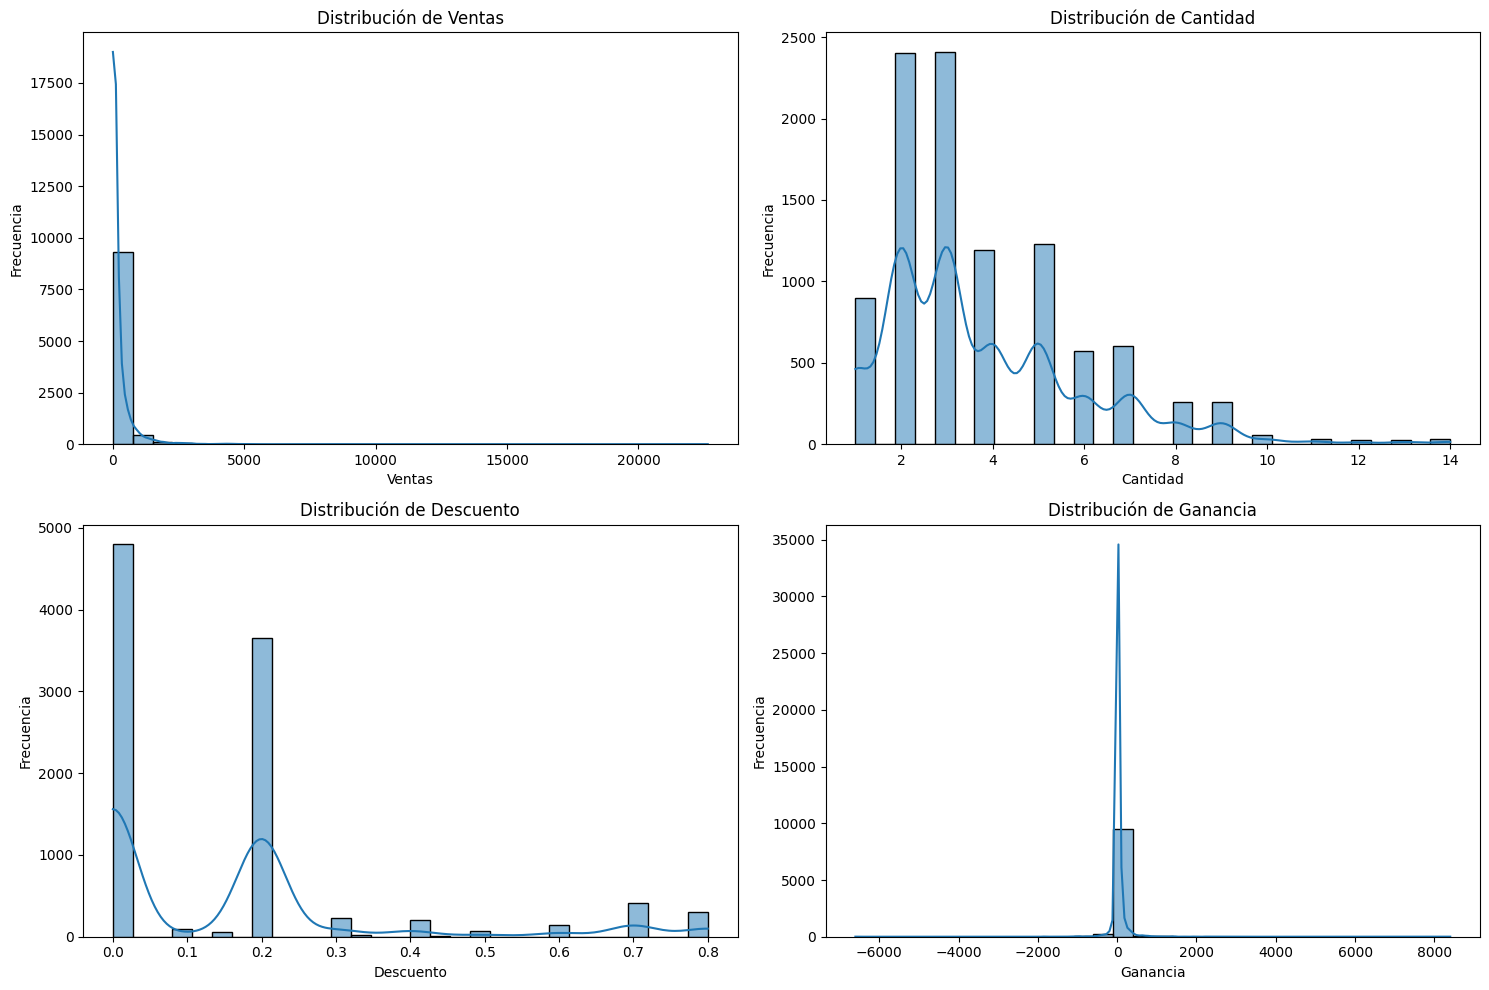

In [4]:
# =====================================================
# PIPELINE DE EXPLORACIÓN DE DATOS
# =====================================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# ===============================
# 1. Tamaño del DataFrame
# ===============================
print("\n" + "="*50)
print("1. TAMAÑO DEL DATAFRAME")
print("="*50)
print(df_original.shape)


# ===============================
# 2. Información general del dataset
# ===============================
print("\n" + "="*50)
print("2. INFORMACIÓN GENERAL DEL DATASET")
print("="*50)
df_original.info()


# ===============================
# 3. Diccionario de categorías por columna (categóricas)
# ===============================
print("\n" + "="*50)
print("3. DICCIONARIO DE CATEGORÍAS (VARIABLES CATEGÓRICAS)")
print("="*50)

columnas_categoricas = [
    'Modo_de_envío', 'Segmento', 'País', 'Ciudad', 
    'Estado', 'Región', 'Categoría', 'Subcategoría'
]

categorias_por_columna = {col: df_original[col].unique().tolist() 
                          for col in columnas_categoricas}

for col, categorias in categorias_por_columna.items():
    print(f"\nColumna: {col}")
    print(f"Categorías: {categorias}")



# ===============================
# 3.1. Análisis de Frecuencia y Visualización (Variables Categóricas)
# ===============================
print("\n" + "="*50)
print("3.1. FRECUENCIA Y VISUALIZACIÓN DE VARIABLES CATEGÓRICAS")
print("="*50)

# Lista de columnas categóricas definida previamente
columnas_categoricas = [
    'Modo_de_envío', 'Segmento', 'País', 
    'Estado', 'Región', 'Categoría', 'Subcategoría'
]


# Itera sobre cada columna categórica para generar un diagrama de barras
for col in columnas_categoricas:
    plt.figure(figsize=(10, 6)) # Define el tamaño de la figura para cada gráfico
    
    # Crea el diagrama de barras de la frecuencia de valores
    # 'value_counts()' cuenta las ocurrencias de cada categoría
    # 'plot(kind='bar')' genera el gráfico de barras
    df_original[col].value_counts().plot(kind='bar', color='skyblue')
    
    # Agrega el título del gráfico, usando el nombre de la columna
    plt.title(f'Distribución de {col}')
    
    # Etiqueta del eje X, usando el nombre de la columna
    plt.xlabel(col)
    
    # Etiqueta del eje Y
    plt.ylabel('Conteo de Registros')
    
    # Rota las etiquetas del eje X si son muy largas para evitar superposiciones
    plt.xticks(rotation=45, ha='right')
    
    # Ajusta el layout para que no se corten las etiquetas
    plt.tight_layout()
    
    # Muestra el gráfico
    plt.show()




# ===============================
# 4. Estadísticas descriptivas (numéricas)
# ===============================
print("\n" + "="*50)
print("4. ESTADÍSTICAS DESCRIPTIVAS")
print("="*50)
print(df_original.describe())


# ===============================
# 5. Valores faltantes por columna
# ===============================
print("\n" + "="*50)
print("5. VALORES FALTANTES")
print("="*50)
print(df_original.isnull().sum())


# ===============================
# 6. Detección de valores atípicos (IQR)
# ===============================
print("\n" + "="*50)
print("6. DETECCIÓN DE OUTLIERS (IQR)")
print("="*50)

columnas_numericas = ['Ventas', 'Cantidad', 'Descuento', 'Ganancia']
total_datos = df_original.shape[0]



def detectar_outliers_iqr(df):
    """
    Detecta y calcula el porcentaje de outliers en cada columna numérica 
    de un DataFrame usando el método del IQR.
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        Conjunto de datos a analizar.
        
    Retorna:
    --------
    pandas.DataFrame
        DataFrame con columnas: ['Columna', 'Num_Outliers', 'Porcentaje_Outliers']
    """
    resultados = []
    columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
    total_datos = df.shape[0]
    
    for col in columnas_numericas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        num_outliers = outliers.count()
        porcentaje_outliers = (num_outliers / total_datos) * 100

        resultados.append({
            'Columna': col,
            'Num_Outliers': num_outliers,
            'Porcentaje_Outliers': round(porcentaje_outliers, 2)
        })
    
    return pd.DataFrame(resultados)

resultado = detectar_outliers_iqr(df_original)
print(resultado)


# ahora con graficos de caja 

plt.figure(figsize=(12, 8))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_original[col])
    plt.title(f'Boxplot para {col}')
plt.tight_layout()
plt.show()

# ===============================
# 6.1. Número de valores duplicados
# ===============================
print("\n" + "="*50)
print("6.1. NÚMERO DE VALORES DUPLICADOS")
print("="*50)

num_duplicados = df_original.duplicated().sum()
print(f"Número de filas duplicadas en el DataFrame: {num_duplicados}")




# ===============================
# 7. Matriz de correlación
# ===============================
print("\n" + "="*50)
print("7. MATRIZ DE CORRELACIÓN")
print("="*50)

matriz_correlacion = df_original[columnas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()


# ===============================
# 7.1. Matriz de dispersión (Pairplot)
# ===============================
print("\n" + "="*50)
print("7.1. MATRIZ DE DISPERSIÓN (PAIRPLOT)")
print("="*50)

# Esto puede tomar un tiempo si tienes muchas columnas numéricas.
# Puedes seleccionar un subconjunto si es necesario.
sns.pairplot(df_original[columnas_numericas])
plt.suptitle('Matriz de Dispersión de Variables Numéricas', y=1.02)
plt.show()



# ===============================
# 8. Distribución de datos (QQ-plot)
# ===============================
print("\n" + "="*50)
print("8. DISTRIBUCIÓN DE DATOS (QQ-PLOT)")
print("="*50)

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    stats.probplot(df_original[col], dist="norm", plot=plt)
    plt.title(f'QQ-plot para {col}')
    plt.show()

# ===============================
# 8.1. Media, Moda y Mediana de variables numéricas
# ===============================
print("\n" + "="*50)
print("8.1. MEDIA, MODA Y MEDIANA DE VARIABLES NUMÉRICAS")
print("="*50)

columnas_numericas = ['Ventas', 'Cantidad', 'Descuento', 'Ganancia']

for col in columnas_numericas:
    media = df_original[col].mean()
    mediana = df_original[col].median()
    moda = df_original[col].mode()[0]
    print(f"\nColumna: {col}")
    print(f"   Media: {media:.2f}")
    print(f"   Mediana: {mediana:.2f}")
    print(f"   Moda: {moda:.2f}")


# ===============================
# 8.2. Distribución de datos numéricos (Histogramas y KDE)
# ===============================
print("\n" + "="*50)
print("8.2. DISTRIBUCIÓN DE DATOS NUMÉRICOS (HISTOGRAMAS Y KDE)")
print("="*50)

plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_original[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Conclusiones de la exploración:

- Tenemos un conjunto de datos pequeño 
- No tenemos valores nulos 
- Tenemos datos de tipo entero y numérico 
- Tenemos rangos distintos en las variables numéricas
- Tenemos diferentes porcentajes de valores atípicos en las variables numéricas
- Tenemos un número de filas duplicadas despreciables
- Las variables numéricas no están correlacionadas linealmente. Lo que indica que todas las variables numéricas son de vital importancia para el análisis ya que no existen multicolinealidad entre ellas
- Las variables numéricas no se distribuyen normalmente. Ya que en el gráfico qq plot, la línea azul no se ajusta a la línea roja y las medidas centrales no son iguales o aproximadamente iguales. También podemos confirmar esto con los gráficos de distribución numéricos (histogramas)


# 4.- Visualizaciones



El análisis de realizará en python, sql y power bi. Esto con fines didácticos y de documentación personal.

En esta sección haremos la limpieza para lograr todas las visualizaciones posibles planteadas al inicio del proyecto. 

Qué tipo de limpieza debemos hacer para obtener visualizaciones de calidad?

- El codigo postal es irrelevante para nuestro analisis, lo eliminamos
- Podemos crear medidas de impacto a partir de Ventas, Cantidad, Descuento, Ganancia:

        Medidas:

            - Margen
            - Venta promedio por unidad
            - Ganancia promedio por unidad

        Columnas:

            - Ganancia por unidad
            - Perdida por descuento

## 4.1.- Limpieza y organización para las visualizaciones

A partir de la expliracion, la limpieza para las visualizaciones será:

- Tenemos diferentes porcentajes de valores atípicos en las variables numéricas



In [ ]:
resultado = detectar_outliers_iqr(df_original)
print(resultado)


         Columna  Num_Outliers  Porcentaje_Outliers
0  Código_Postal             0                 0.00
1         Ventas          1167                11.68
2       Cantidad           170                 1.70
3      Descuento           856                 8.57
4       Ganancia          1881                18.82


Es necesario corregir los valores atipicos?

- codigo postan no hay nada que hacer
- ventas: El porcentaje de valores atípicos de ventas es muy bajo podemos asumir que las ventas variar de manera excéntrica en algunos periodos, tambien podemos asumir que un porcentaje menor fue un error de registro o captura
- cantidad: despreciable
- descuento: despreciable
- ganancia: es logico que tengamos una cuarta parte de atipicos en la ganancia ya que tenemos nultiples regiones y periodos.

Por lo tanto asumiremos que los datos atípicos son Parte de la naturaleza de los datos y no por un error de captura o tipografía

In [21]:
import pandas as pd
df_visualizaciones = pd.read_csv("ventas_original_español.csv")
#borrar la columna codigo postal
df_visualizaciones_limpio = df_visualizaciones.drop(columns=['Código_Postal', 'País'])
#guardar el nuevo dataframe
df_visualizaciones_limpio.to_csv("ventas_visualizaciones.csv", index=False)

df_visualizaciones_limpio.head()

,Modo_de_envío,Segmento,Ciudad,Estado,Región,Categoría,Subcategoría,Ventas,Cantidad,Descuento,Ganancia
0,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 4.2.- Visualizaciones de negocio

In [22]:

df_visualizaciones_limpio.head()

,Modo_de_envío,Segmento,Ciudad,Estado,Región,Categoría,Subcategoría,Ventas,Cantidad,Descuento,Ganancia
0,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


1. **Análisis descriptivo:**
    - Identificar patrones de ventas por región, estado y ciudad.
    - Analizar cuáles son los productos y categorías más rentables.
    - Ver el impacto de los descuentos en las ganancias.
    - Detectar tendencias de compra por segmento de cliente.
2. **Análisis diagnóstico:**
    - Entender por qué ciertas regiones o productos tienen márgenes más bajos.
    - Evaluar si el modo de envío influye en el margen de ganancia.
3. **Análisis predictivo / estadístico (en caso de ser posible):**
    - Predecir ventas futuras por región o categoría usando series de tiempo o modelos de machine learning.
    - Identificar clientes o segmentos con mayor probabilidad de compras repetidas.
4. **Análisis prescriptivo (opcional):**
    - Recomendaciones sobre asignación de inventario o ajustes de descuentos para maximizar beneficios.

### 4.2.1.- Objetivo inicial

#### Ventas por región, estado y ciudad

In [23]:
# Ventas totales por región, estado y ciudad
ventas_por_ubicacion = df_visualizaciones_limpio.groupby(['Región', 'Estado', 'Ciudad'])['Ventas'].sum().reset_index()
display(ventas_por_ubicacion)

,Región,Estado,Ciudad,Ventas
0,Central,Illinois,Arlington Heights,14.112
1,Central,Illinois,Aurora,7572.968
2,Central,Illinois,Bloomington,963.940
3,Central,Illinois,Bolingbrook,218.308
4,Central,Illinois,Buffalo Grove,831.399
...,...,...,...,...
599,West,Washington,Renton,1242.632
600,West,Washington,Seattle,119540.742
601,West,Washington,Spokane,2027.918
602,West,Washington,Vancouver,686.836


C:\Users\Fernando\AppData\Local\Temp\ipykernel_11252\1743975553.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_por_region, x='Región', y='Ventas', palette='viridis')


Text(0.5, 0, 'Región')

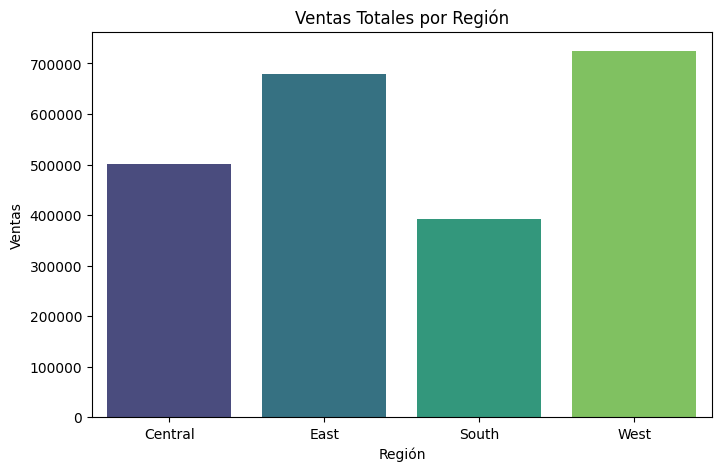

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ventas totales por región
ventas_por_region = df_visualizaciones_limpio.groupby('Región')['Ventas'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=ventas_por_region, x='Región', y='Ventas', palette='viridis')
plt.title('Ventas Totales por Región')
plt.xlabel('Región')

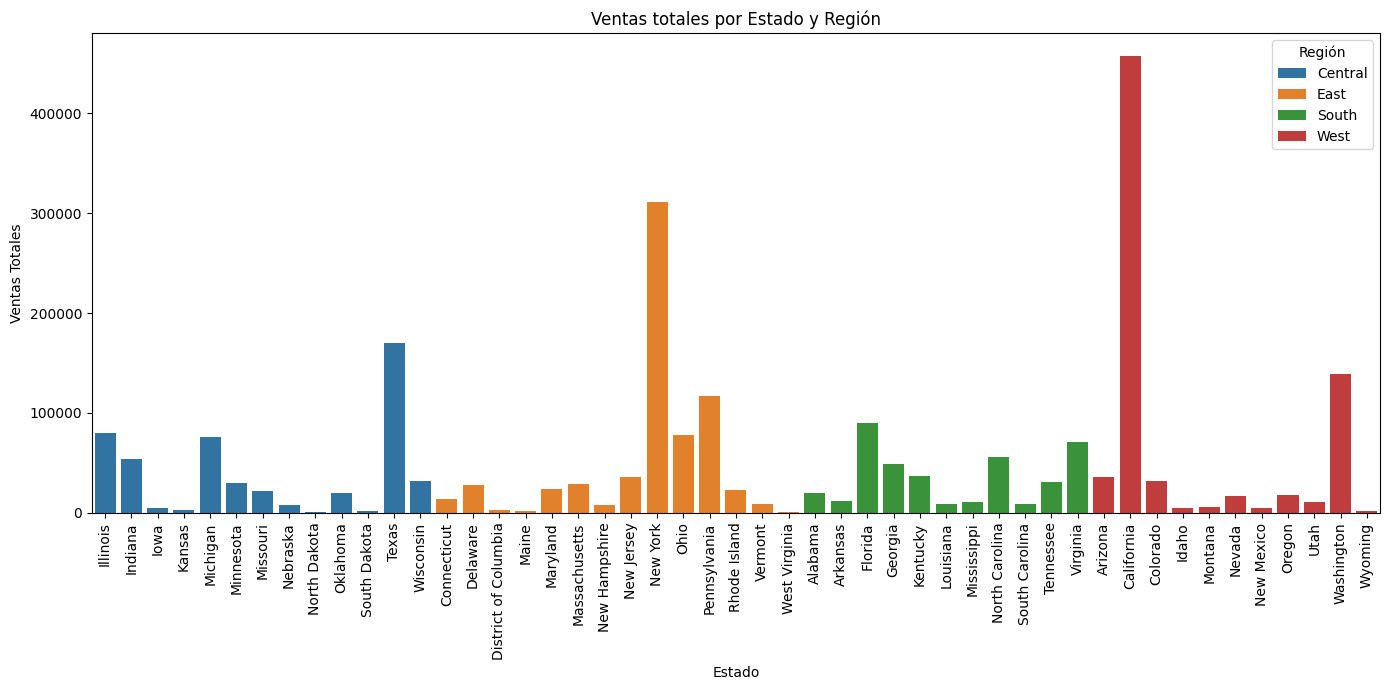

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupa ventas por región y estado
ventas_estado = df_visualizaciones_limpio.groupby(['Región', 'Estado'])['Ventas'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=ventas_estado, x='Estado', y='Ventas', hue='Región')
plt.xticks(rotation=90)
plt.title('Ventas totales por Estado y Región')
plt.xlabel('Estado')
plt.ylabel('Ventas Totales')
plt.legend(title='Región')
plt.tight_layout()
plt.show()

#### Productos y categorías más rentables.

Para saber cuáles son los productos y categorías más rentables, poemos agrupar por "Categoría" y "Subcategoría" y sumar la ganancia. Así identificas las más rentables por el total de ganancia obtenida.



In [26]:
# Categorías más rentables
categorias_rentables = df_visualizaciones_limpio.groupby('Categoría')['Ganancia'].sum().sort_values(ascending=False)
#convertir a dataframe
categorias_rentables = categorias_rentables.reset_index()


#categorias de "categoria"
print("Las categorias de la columna 'categoria' son :", categorias_rentables['Categoría'].unique().tolist())

print(type(categorias_rentables))
print("Ganancia total por categoría:")
display(categorias_rentables)



Las categorias de la columna 'categoria' son : ['Technology', 'Office Supplies', 'Furniture']
<class 'pandas.core.frame.DataFrame'>
Ganancia total por categoría:


,Categoría,Ganancia
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


C:\Users\Fernando\AppData\Local\Temp\ipykernel_11252\3112756769.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categorias_rentables, x='Categoría', y='Ganancia', palette='crest')


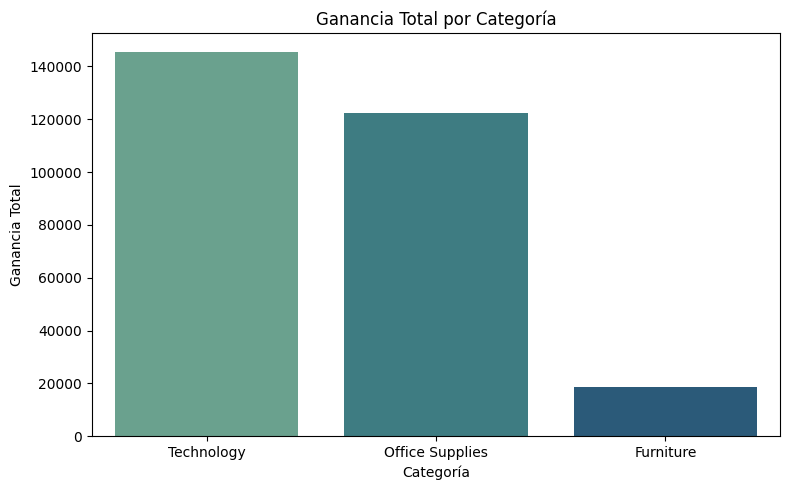

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de barras para mostrar la ganancia total por categoría
plt.figure(figsize=(8, 5))
sns.barplot(data=categorias_rentables, x='Categoría', y='Ganancia', palette='crest')
plt.title('Ganancia Total por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ganancia Total')
plt.tight_layout()
plt.show()

In [28]:
# Subcategorías más rentables
subcategorias_rentables = df_visualizaciones_limpio.groupby('Subcategoría')['Ganancia'].sum().sort_values(ascending=False)
subcategorias_rentables = subcategorias_rentables.reset_index()


#categorias de "categoria"
print("Las categorias de la columna 'subcategoria' son :", subcategorias_rentables['Subcategoría'].unique().tolist())

print(type(subcategorias_rentables))
print("\nGanancia total por subcategoría:")
display(subcategorias_rentables)

Las categorias de la columna 'subcategoria' son : ['Copiers', 'Phones', 'Accessories', 'Paper', 'Binders', 'Chairs', 'Storage', 'Appliances', 'Furnishings', 'Envelopes', 'Art', 'Labels', 'Machines', 'Fasteners', 'Supplies', 'Bookcases', 'Tables']
<class 'pandas.core.frame.DataFrame'>

Ganancia total por subcategoría:


,Subcategoría,Ganancia
0,Copiers,55617.8249
1,Phones,44515.7306
2,Accessories,41936.6357
3,Paper,34053.5693
4,Binders,30221.7633
5,Chairs,26590.1663
6,Storage,21278.8264
7,Appliances,18138.0054
8,Furnishings,13059.1436
9,Envelopes,6964.1767


C:\Users\Fernando\AppData\Local\Temp\ipykernel_11252\3288077259.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcategorias_rentables, x='Subcategoría', y='Ganancia', palette='flare')


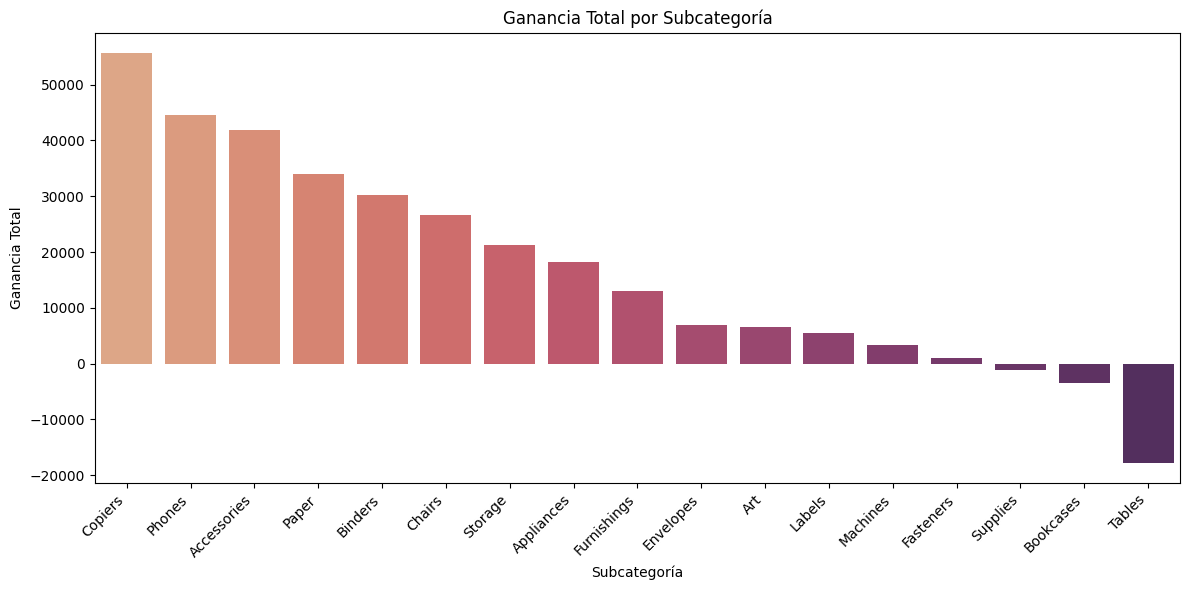

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de barras para mostrar la ganancia total por subcategoría
plt.figure(figsize=(12, 6))
sns.barplot(data=subcategorias_rentables, x='Subcategoría', y='Ganancia', palette='flare')
plt.title('Ganancia Total por Subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Ganancia Total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Impacto de los descuentos en las ganancias.

In [30]:
# Tabla resumen del impacto de los descuentos en las ganancias
tabla_descuento_ganancia = df_visualizaciones_limpio.groupby('Descuento')['Ganancia'].mean().reset_index()
tabla_descuento_ganancia = tabla_descuento_ganancia.sort_values(by='Descuento')
tabla_descuento_ganancia = tabla_descuento_ganancia.rename(columns={'Ganancia': 'Ganancia_promedio'})

print("Ganancia promedio por nivel de descuento:")
display(tabla_descuento_ganancia)


Ganancia promedio por nivel de descuento:


,Descuento,Ganancia_promedio
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


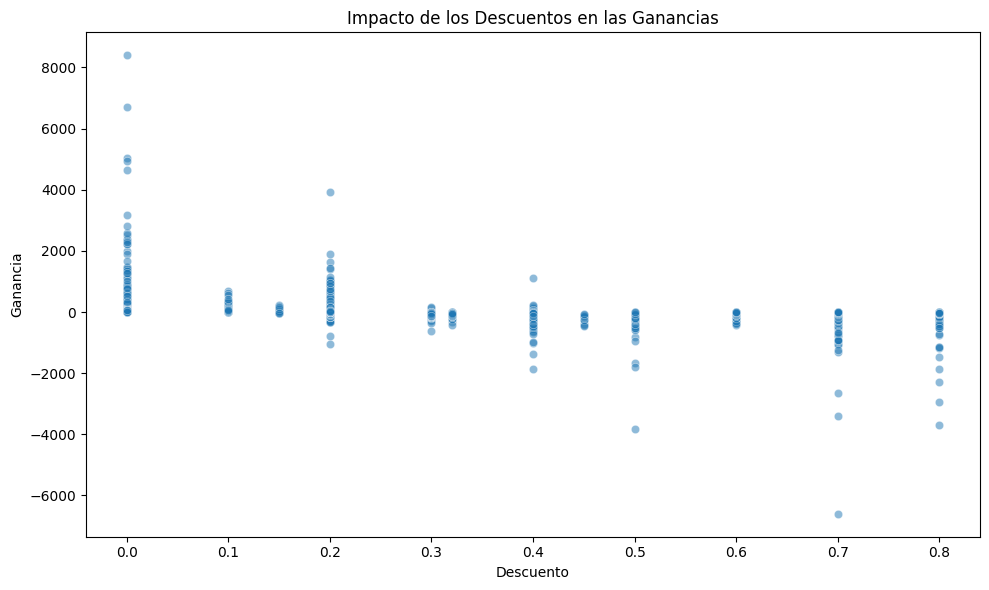

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Relación entre descuento y ganancia
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_visualizaciones, x='Descuento', y='Ganancia', alpha=0.5)
plt.title('Impacto de los Descuentos en las Ganancias')
plt.xlabel('Descuento')
plt.ylabel('Ganancia')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Ganancia Promedio')

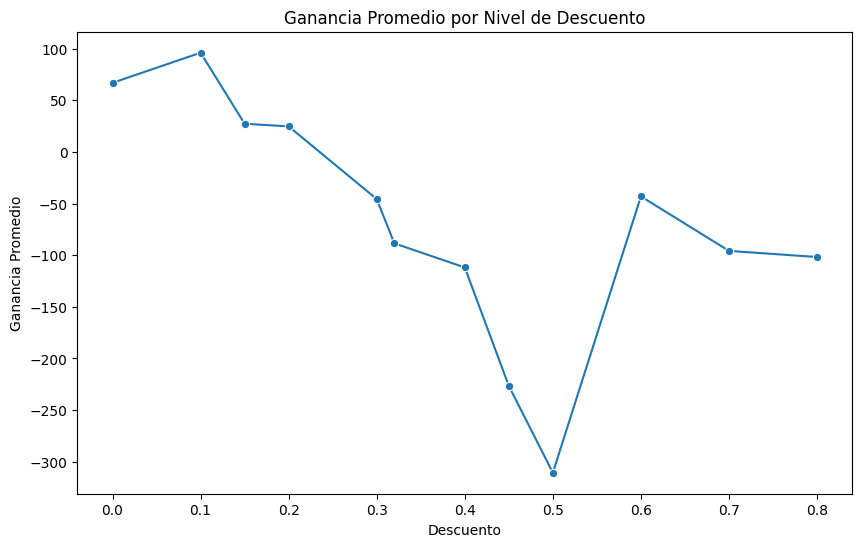

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcula la ganancia promedio por nivel de descuento
tabla_descuento_ganancia = df_visualizaciones_limpio.groupby('Descuento')['Ganancia'].mean().reset_index()
tabla_descuento_ganancia = tabla_descuento_ganancia.sort_values(by='Descuento')
tabla_descuento_ganancia = tabla_descuento_ganancia.rename(columns={'Ganancia': 'Ganancia_promedio'})

# Grafica la ganancia promedio por nivel de descuento
plt.figure(figsize=(10, 6))
sns.lineplot(data=tabla_descuento_ganancia, x='Descuento', y='Ganancia_promedio', marker='o')
plt.title('Ganancia Promedio por Nivel de Descuento')
plt.xlabel('Descuento')
plt.ylabel('Ganancia Promedio')

#### Tendencias de compra por segmento de cliente.

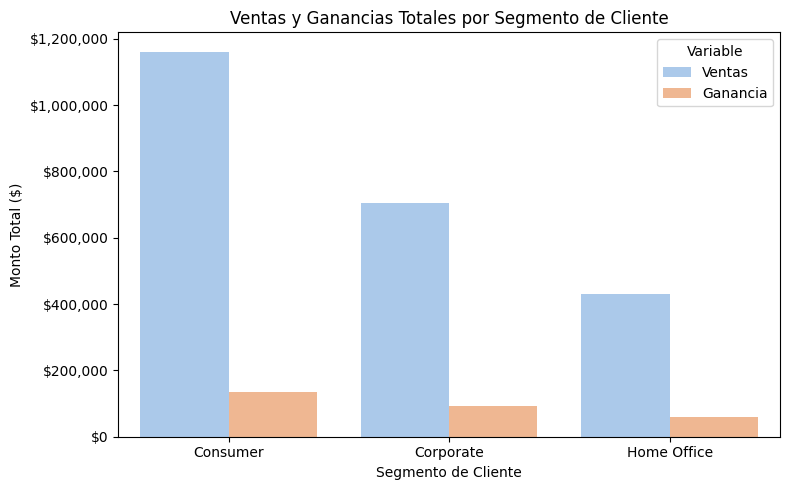

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick  # <-- Aquí está el truco

# Agrupa ventas y ganancias por segmento de cliente
segmento_resumen = df_visualizaciones_limpio.groupby('Segmento')[['Ventas', 'Ganancia']].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=segmento_resumen.melt(id_vars='Segmento', value_vars=['Ventas', 'Ganancia']),
    x='Segmento', y='value', hue='variable', palette='pastel'
)

plt.title('Ventas y Ganancias Totales por Segmento de Cliente')
plt.xlabel('Segmento de Cliente')
plt.ylabel('Monto Total ($)')

# ---- Escala explícita ----
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))  
# Ejemplo: $1,000 -> $1,000 (con comas)

plt.legend(title='Variable')
plt.tight_layout()
plt.show()


#### Por qué ciertas regiones o productos tienen márgenes más bajos

In [34]:
#Crear columna de margen
df_visualizaciones_limpio['margen'] = df_visualizaciones_limpio['Ganancia'] / df_visualizaciones_limpio['Ventas']
df_visualizaciones_limpio.head()

,Modo_de_envío,Segmento,Ciudad,Estado,Región,Categoría,Subcategoría,Ventas,Cantidad,Descuento,Ganancia,margen
0,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,0.1600
1,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820,0.3000
2,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,0.4700
3,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-0.4000
4,Standard Class,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,0.1125


In [35]:
# Tabla resumen
tabla_margen_region = df_visualizaciones_limpio.groupby('Región').agg(
    margen_promedio=('margen', 'mean'),
    ganancia_total=('Ganancia', 'sum'),
    ventas_total=('Ventas', 'sum')
).reset_index()
display(tabla_margen_region)



,Región,margen_promedio,ganancia_total,ventas_total
0,Central,-0.104073,39706.3625,501239.8908
1,East,0.167227,91522.7800,678781.2400
2,South,0.163519,46749.4303,391721.9050
3,West,0.219487,108418.4489,725457.8245


In [40]:
# Tabla de margen promedio por subcategoría y producto
tabla_margen_subcat = df_visualizaciones_limpio.groupby(['Subcategoría']).agg(
    margen_promedio=('margen', 'mean'),
    ganancia_total=('Ganancia', 'sum'),
    ventas_total=('Ventas', 'sum'),
    cantidad_total=('Cantidad', 'sum')
).reset_index()

display(tabla_margen_subcat)

,Subcategoría,margen_promedio,ganancia_total,ventas_total,cantidad_total
0,Accessories,0.218210,41936.6357,167380.3180,2976
1,Appliances,-0.156869,18138.0054,107532.1610,1729
2,Art,0.251646,6527.7870,27118.7920,3000
3,Binders,-0.199595,30221.7633,203412.7330,5974
4,Bookcases,-0.126640,-3472.5560,114879.9963,868
5,Chairs,0.043900,26590.1663,328449.1030,2356
6,Copiers,0.317194,55617.8249,149528.0300,234
7,Envelopes,0.423140,6964.1767,16476.4020,906
8,Fasteners,0.299171,949.5182,3024.2800,914
9,Furnishings,0.137066,13059.1436,91705.1640,3563


C:\Users\Fernando\AppData\Local\Temp\ipykernel_11252\1211174535.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_margen_region, x='Región', y='margen_promedio', palette='coolwarm')


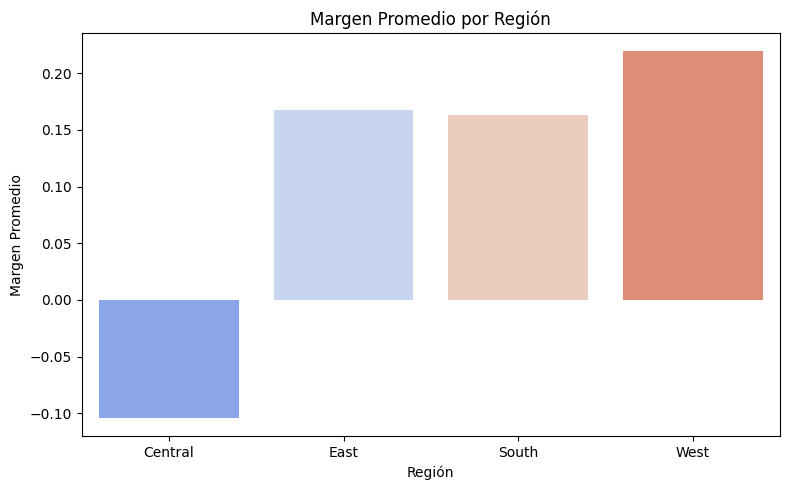

In [41]:
# Gráfico de barras
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=tabla_margen_region, x='Región', y='margen_promedio', palette='coolwarm')
plt.title('Margen Promedio por Región')
plt.xlabel('Región')
plt.ylabel('Margen Promedio')
plt.tight_layout()
plt.show()

#### Comparación de modo de envío y margen

C:\Users\Fernando\AppData\Local\Temp\ipykernel_11252\3417148818.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_margen_envio, x='Modo_de_envío', y='margen_promedio', palette='Set2')


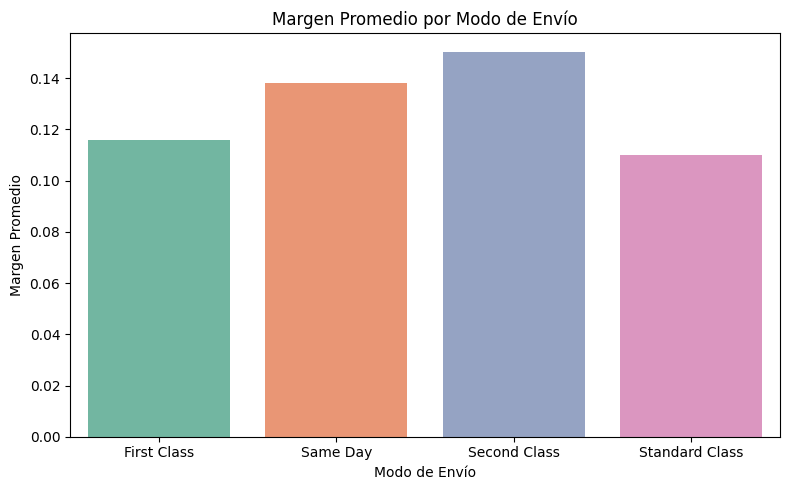

In [38]:
# Gráfico de barras: modo de envío vs margen promedio
tabla_margen_envio = df_visualizaciones_limpio.groupby('Modo_de_envío').agg(
    margen_promedio=('margen', 'mean'),
    ganancia_total=('Ganancia', 'sum'),
    ventas_total=('Ventas', 'sum')
).reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=tabla_margen_envio, x='Modo_de_envío', y='margen_promedio', palette='Set2')
plt.title('Margen Promedio por Modo de Envío')
plt.xlabel('Modo de Envío')
plt.ylabel('Margen Promedio')
plt.tight_layout()
plt.show()


### 4.2.1.- Objetivos adicionales planteados por el equipo técnico

Estas visualizaciones se harán con power bi con ayuda de sql. Aquí se deja la referencia para seguir el flujo lógico de trabajo

- Ciudades lider en ventas por región (cuáles ciudades venden más por región)
- Relación entre el modo de envío y el segmento de clientes
- Comparar mismos productos en diferentes regiones y observar el comportamiento de estos
- Top 10 productos estrella en ventas y ganancias
- Ganancia neta según segmento, región, categoria y producto (subcategoria)


In [21]:
import pandas as pd
df_visualizaciones_limpio = pd.read_csv("ventas_visualizaciones.csv")
df_visualizaciones_limpio.head()

,Modo_de_envío,Segmento,Ciudad,Estado,Región,Categoría,Subcategoría,Ventas,Cantidad,Descuento,Ganancia
0,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


Con fin didáctico, estos objetivos 4.2.1 se ejcutarán en power bi y sql

- También se harán las consultas sql desde aquí
- Los pasos principales que se hagan en Power bi se documentarán aquí. 


##### SQL

In [6]:
import mysql.connector
import pandas as pd

# Paso 1: Conectar a la base de datos MySQL
conexion = mysql.connector.connect(
    host='localhost',        # Cambia si usas otro host
    user='root',       # Ej. 'root'
    password='Admin123*',
    database='supermarket'   # Ej. 'ventas2025'
)


###### Ciudades lider en ventas por región (cuáles ciudades venden más por región)


In [7]:


consulta1 = """

    SELECT 
        Region,
        Ciudad,
        SUM(Ventas) AS Ventas_Totales
    FROM ventas_visualizaciones
    GROUP BY Region, Ciudad
    ORDER BY Region, Ventas_Totales DESC;
    
"""




In [8]:
# Ejecutar la consulta y guardar el resultado en un DataFrame
df_consulta1 = pd.read_sql(consulta1, conexion)

# Trabajar con el DataFrame
display(df_consulta1.head())         # Mostrar primeras filas




C:\Users\Fernando\AppData\Local\Temp\ipykernel_11252\3273548974.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_consulta1 = pd.read_sql(consulta1, conexion)


,Region,Ciudad,Ventas_Totales
0,Central,Houston,64504.7604
1,Central,Chicago,48539.5410
2,Central,Detroit,42446.9440
3,Central,San Antonio,21843.5280
4,Central,Dallas,20131.9322


###### Relación entre el modo de envío y el segmento de clientes


In [9]:
consulta2 = """

 SELECT 
    Modo_de_envio,
    Segmento,
    COUNT(*) AS Total_Pedidos,
    SUM(Ventas) AS Ventas_Totales
FROM ventas_visualizaciones
GROUP BY Modo_de_envio, Segmento
ORDER BY Modo_de_envio, Ventas_Totales DESC;

"""

In [10]:
# Ejecutar la consulta y guardar el resultado en un DataFrame
df_consulta2 = pd.read_sql(consulta2, conexion)

# Trabajar con el DataFrame
display(df_consulta2.head())         # Mostrar primeras filas


C:\Users\Fernando\AppData\Local\Temp\ipykernel_11252\2698472865.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_consulta2 = pd.read_sql(consulta2, conexion)


,Modo_de_envio,Segmento,Total_Pedidos,Ventas_Totales
0,First Class,Consumer,769,159168.9650
1,First Class,Corporate,485,105858.4699
2,First Class,Home Office,284,86400.9880
3,Same Day,Consumer,317,60596.3590
4,Same Day,Corporate,114,45121.3230


###### Comparar mismos productos en diferentes regiones y observar el comportamiento de estos


In [11]:
consulta3 = """
SELECT 
    Subcategoria,
    Region,
    SUM(Ventas) AS Ventas_Totales,
    SUM(Ganancia) AS Ganancia_Total
FROM ventas_visualizaciones
GROUP BY Subcategoria, Region
ORDER BY Subcategoria, Region;


   
   
"""

In [12]:
# Ejecutar la consulta y guardar el resultado en un DataFrame
df_consulta3 = pd.read_sql(consulta3, conexion)

# Trabajar con el DataFrame
display(df_consulta3.head())  

C:\Users\Fernando\AppData\Local\Temp\ipykernel_11252\4258384143.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_consulta3 = pd.read_sql(consulta3, conexion)


,Subcategoria,Region,Ventas_Totales,Ganancia_Total
0,Accessories,Central,33956.076,7251.6306
1,Accessories,East,45033.372,11195.8644
2,Accessories,South,27276.754,7004.5424
3,Accessories,West,61114.116,16484.5983
4,Appliances,Central,23582.033,-2638.6175


###### Top 10 productos estrella en ventas y ganancias


In [13]:
consulta4 = """

   SELECT 
	Subcategoria,
	SUM(Ventas) AS Ventas_Totales,
	SUM(Ganancia) AS Ganancia_Total
FROM ventas_visualizaciones
GROUP BY Subcategoria
ORDER BY Ventas_Totales DESC, Ganancia_Total DESC
LIMIT 10;

"""

# Ejecutar la consulta y guardar el resultado en un DataFrame
df_consulta4 = pd.read_sql(consulta4, conexion)

# Trabajar con el DataFrame
display(df_consulta4.head())  

C:\Users\Fernando\AppData\Local\Temp\ipykernel_11252\2953578806.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_consulta4 = pd.read_sql(consulta4, conexion)


,Subcategoria,Ventas_Totales,Ganancia_Total
0,Phones,330007.054,44515.7306
1,Chairs,328449.103,26590.1663
2,Storage,223843.608,21278.8264
3,Tables,206965.532,-17725.4811
4,Binders,203412.733,30221.7633


###### Ganancia neta según segmento, región, categoria y producto (subcategoria)

In [14]:
consulta5 = """

   SELECT 
    Segmento,
    Region,
    Categoria,
    Subcategoria,
    SUM(Ganancia) AS Ganancia_Neta
FROM ventas_visualizaciones
GROUP BY Segmento, Region, Categoria, Subcategoria
ORDER BY Segmento, Region, Categoria, Ganancia_Neta DESC;

    
"""

In [15]:
# Ejecutar la consulta y guardar el resultado en un DataFrame
df_consulta5 = pd.read_sql(consulta5, conexion)

# Trabajar con el DataFrame
display(df_consulta5.head())  

C:\Users\Fernando\AppData\Local\Temp\ipykernel_11252\711109861.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_consulta5 = pd.read_sql(consulta5, conexion)


,Segmento,Region,Categoria,Subcategoria,Ganancia_Neta
0,Consumer,Central,Furniture,Chairs,2920.9013
1,Consumer,Central,Furniture,Furnishings,-1454.0524
2,Consumer,Central,Furniture,Bookcases,-1497.1260
3,Consumer,Central,Furniture,Tables,-3964.1571
4,Consumer,Central,Office Supplies,Paper,2914.6377


In [17]:
# Cerrar la conexión
conexion.close()

Una vez hechas las consultas desde una base de datos externa con sql, tenemos los dataframes listos para graficar. Eso se dejará como mejora del proyecto

##### Power BI

Aquí podemos llevarnos todas las visualizaciones creadas a power bi y añadir indicadores clave y crear un dashboard. Solo se cargarán en el archivo y el dashboard se hará hasta tener las graficas o informacion del modelado

Guardamos las tablas extraidas de sql

In [16]:
import pandas as pd

# Recorremos del 1 al 5
for i in range(1, 6):
    # Construir el nombre del DataFrame dinámicamente
    df = globals()[f"df_consulta{i}"]
    
    # Guardar en CSV
    df.to_csv(f"df_consulta{i}.csv", index=False, encoding="utf-8-sig")
    
    print(f"df_consulta{i}.csv guardado correctamente")


df_consulta1.csv guardado correctamente
df_consulta2.csv guardado correctamente
df_consulta3.csv guardado correctamente
df_consulta4.csv guardado correctamente
df_consulta5.csv guardado correctamente


Guardamos las tablas extraidas de sql

In [44]:
import pandas as pd

# Lista con (nombre_variable, dataframe)
tablas = [
    ("tabla_margen_envio", tabla_margen_envio),
    ("tabla_margen_subcat", tabla_margen_subcat),
    ("segmento_resumen", segmento_resumen),
    ("tabla_descuento_ganancia", tabla_descuento_ganancia),
    ("subcategorias_rentables", subcategorias_rentables),
    ("categorias_rentables", categorias_rentables),
    ("ventas_estado", ventas_estado),
    ("ventas_por_region", ventas_por_region),
]

# Recorrer y guardar con el formato 01_nombre.csv
for i, (nombre_var, df) in enumerate(tablas, start=1):
    nombre = f"{i:02}_{nombre_var}.csv"
    df.to_csv(nombre, index=False, encoding="utf-8-sig")
    print(f"{nombre} guardado correctamente")



01_tabla_margen_envio.csv guardado correctamente
02_tabla_margen_subcat.csv guardado correctamente
03_segmento_resumen.csv guardado correctamente
04_tabla_descuento_ganancia.csv guardado correctamente
05_subcategorias_rentables.csv guardado correctamente
06_categorias_rentables.csv guardado correctamente
07_ventas_estado.csv guardado correctamente
08_ventas_por_region.csv guardado correctamente


#### 